# 5.5 — Sensibilidades: DV01, key-rate durations, jacobiano de calibración

Con la curva construida (5.2-5.4), la pregunta que sigue es cuánto se mueve el valor de un instrumento cuando el mercado se mueve — el paso obligado antes de cualquier gestión de riesgo. Este notebook cierra M5 con tres sensibilidades progresivamente más finas: **DV01** (¿cuánto vale un movimiento paralelo de toda la curva?), **key-rate durations** (¿a qué parte de la curva es sensible cada instrumento?) y el **jacobiano de calibración** (¿cómo se propaga un error de una cotización de mercado hacia la curva zero completa?).

Una precisión conceptual que vale la pena adelantar, porque es fácil confundirla y el notebook la separa explícitamente: "DV01 de un swap" puede significar dos cosas distintas — la sensibilidad a la **propia tasa par** del swap (una identidad algebraica exacta) o la sensibilidad a un **shock paralelo de la curva de descuento** (una cantidad relacionada pero no idéntica, y la que realmente importa para gestión de riesgo). Confundirlas produce un error sistemático del orden de varios puntos porcentuales, no redondeo — se cuantifica en la Sección 1.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.curves import DiscountCurve
from qflib.plotting import apply_style

apply_style()

times = np.array([1 / 12, 3 / 12, 6 / 12] + list(range(1, 11)), dtype=float)
dfs = nelson_siegel_df(times)
curve = DiscountCurve(times, dfs)

payment_times_10y = np.arange(1, 11, dtype=float)
K10 = par_swap_rate(curve.df, payment_times_10y)
print(f"Swap 10Y par rate = {K10:.6%}")
print("Sin Monte Carlo -- sensibilidades son diferencias finitas y formulas cerradas deterministas.")

Swap 10Y par rate = 4.578601%
Sin Monte Carlo -- sensibilidades son diferencias finitas y formulas cerradas deterministas.


## 1. DV01: dos definiciones que no son lo mismo

Sea $V(K,y)=(1-P_y(0,T_n))-K\sum_i\tau_iP_y(0,T_i)$ el valor de un swap receptor de flotante, donde $P_y$ denota la curva de descuento tras un desplazamiento $y$ (en cualquier sentido que se defina) y $K$ es la tasa fija.

**Sensibilidad a la propia tasa par ($\partial V/\partial K$).** $V$ es **lineal** en $K$ — la anualidad $\sum_i\tau_iP(0,T_i)$ no depende de $K$ — así que
$$
\frac{\partial V}{\partial K} = -\sum_i\tau_iP(0,T_i) \qquad\text{(identidad exacta, sin aproximación)}.
$$
Esta es la cantidad que casi todos los libros llaman "DV01 $\approx$ anualidad" — y es **exacta** para esta sensibilidad específica, no una aproximación de primer orden.

**Sensibilidad a un shock paralelo de la curva zero ($\partial V/\partial y$, con $P_y(0,T_i)=P(0,T_i)e^{-yT_i}$).** Aquí $K$ se mantiene fija y es la curva la que se mueve — la pregunta de gestión de riesgo real ("¿cuánto pierdo si las tasas suben 1bp?"). Derivando directamente:
$$
\frac{\partial P_y(0,T_i)}{\partial y}\bigg|_{y=0} = -T_i\,P(0,T_i)
\quad\Longrightarrow\quad
\boxed{\frac{\partial V}{\partial y}\bigg|_{y=0} = T_n\,P(0,T_n) + K\sum_i\tau_iT_i\,P(0,T_i)}.
$$
Nótese el factor $T_i$ extra dentro de la suma: un shock paralelo de la curva zero pesa **más** los flujos lejanos (su discount factor es más sensible a un cambio en la tasa continua, precisamente porque se acumula sobre más tiempo) — la anualidad simple no captura eso. Las dos cantidades sólo coinciden si todos los flujos cayeran en el mismo instante; con flujos distribuidos en 10 años, difieren por un factor del orden del 4% en este ejemplo, nada despreciable para un libro de swaps grande.

Este notebook usa la **segunda** definición (shock paralelo) para todo lo que sigue — es la que suma correctamente sobre key-rate durations y la que corresponde a lo que un sistema de riesgo real reporta como "DV01".

In [2]:
def swap_pv(curve_df_fn, K, payment_times):
    '''PV of a receive-float/pay-fixed swap, single-curve (Section 1).'''
    t = np.asarray(payment_times, dtype=float)
    d = curve_df_fn(t)
    tau = np.diff(np.concatenate([[0.0], t]))
    return (1.0 - d[-1]) - K * np.sum(tau * d)


def parallel_shift_curve(times, dfs, y_bp):
    '''Curve with every zero rate shifted by y_bp basis points (Section 1).'''
    z = -np.log(dfs) / times
    return DiscountCurve(times, np.exp(-(z + y_bp * 1e-4) * times))


annuity_10y = np.sum(np.diff(np.concatenate([[0.0], payment_times_10y])) * curve.df(payment_times_10y))
dv01_own_rate = annuity_10y * 1e-4   # exacto: dV/dK * 1bp

t, tau = payment_times_10y, np.diff(np.concatenate([[0.0], payment_times_10y]))
d = curve.df(t)
dv01_parallel_analytic = (t[-1] * d[-1] + K10 * np.sum(tau * t * d)) * 1e-4

curve_up = parallel_shift_curve(times, dfs, 1.0)
curve_dn = parallel_shift_curve(times, dfs, -1.0)
dv01_parallel_fd = (swap_pv(curve_up.df, K10, payment_times_10y)
                     - swap_pv(curve_dn.df, K10, payment_times_10y)) / 2.0

print(f"DV01 vs propia tasa par (= anualidad * 1bp)     = {dv01_own_rate:.8f}")
print(f"DV01 vs shock paralelo, analitico                = {dv01_parallel_analytic:.8f}")
print(f"DV01 vs shock paralelo, bump-and-reprice (+-1bp) = {dv01_parallel_fd:.8f}")
print(f"\nrazon (paralelo / propia tasa) = {dv01_parallel_analytic/dv01_own_rate:.4f}  "
      f"-- confundir las dos definiciones subestima el riesgo real en "
      f"{(dv01_parallel_analytic/dv01_own_rate - 1):.2%}")

DV01 vs propia tasa par (= anualidad * 1bp)     = 0.00079051
DV01 vs shock paralelo, analitico                = 0.00082350
DV01 vs shock paralelo, bump-and-reprice (+-1bp) = 0.00082350

razon (paralelo / propia tasa) = 1.0417  -- confundir las dos definiciones subestima el riesgo real en 4.17%


In [3]:
for bp in (1.0, 5.0):
    curve_up_b = parallel_shift_curve(times, dfs, bp)
    curve_dn_b = parallel_shift_curve(times, dfs, -bp)
    fd = (swap_pv(curve_up_b.df, K10, payment_times_10y) - swap_pv(curve_dn_b.df, K10, payment_times_10y)) / (2 * bp)
    print(f"bump +-{bp}bp: DV01 (por bp) = {fd:.8f}  vs analitico = {dv01_parallel_analytic:.8f}  "
          f"diff = {fd - dv01_parallel_analytic:.2e}")

bump +-1.0bp: DV01 (por bp) = 0.00082350  vs analitico = 0.00082350  diff = 1.22e-10
bump +-5.0bp: DV01 (por bp) = 0.00082351  vs analitico = 0.00082350  diff = 3.06e-09


## 2. Key-rate durations: sensibilidad nodo por nodo

En vez de mover **toda** la curva, se mueve **un solo nodo** de la retícula bootstrapeada (manteniendo los demás fijos) y se mide el cambio de valor — esto exige interpolar entre nodos (5.4), así que la KRD hereda algo de la forma del interpolador usado, aunque con log-lineal el efecto queda contenido en los dos tramos adyacentes al nodo (5.4 §4). La propiedad que hace estas cantidades útiles como *descomposición* del riesgo: la suma de todas las KRD debe reproducir el DV01 paralelo de la Sección 1, porque un shock paralelo **es**, por linealidad de la interpolación en cada tramo, la suma de mover cada nodo individualmente.

  nodo (t) |   KRD (por bp)
---------------------------
    0.0833 |     0.00000000
    0.2500 |     0.00000000
    0.5000 |     0.00000000
    1.0000 |     0.00000440
    2.0000 |     0.00000843
    3.0000 |     0.00001208
    4.0000 |     0.00001538
    5.0000 |     0.00001836
    6.0000 |     0.00002103
    7.0000 |     0.00002344
    8.0000 |     0.00002559
    9.0000 |     0.00002751
   10.0000 |     0.00066727

suma de KRDs = 0.00082350  vs  DV01 paralelo = 0.00082350  (diff = 1.22e-10)


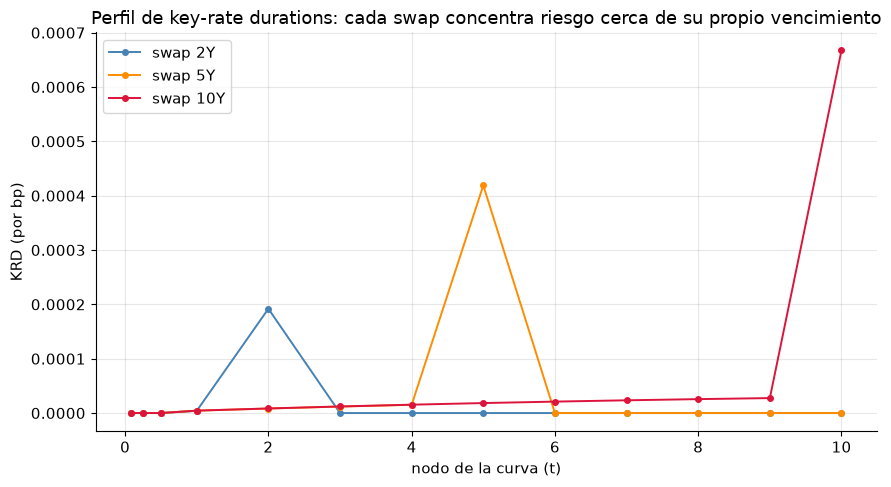

In [4]:
def bump_single_node(times, dfs, node_idx, bp):
    '''Curve with only one node's zero rate shifted (Section 2).'''
    z = -np.log(dfs) / times
    z_bumped = z.copy()
    z_bumped[node_idx] += bp * 1e-4
    return DiscountCurve(times, np.exp(-z_bumped * times))


def key_rate_durations(times, dfs, K, payment_times, bp=1.0):
    krds = np.zeros(len(times))
    for i in range(len(times)):
        c_up = bump_single_node(times, dfs, i, bp)
        c_dn = bump_single_node(times, dfs, i, -bp)
        krds[i] = (swap_pv(c_up.df, K, payment_times) - swap_pv(c_dn.df, K, payment_times)) / (2 * bp)
    return krds


krd_10y = key_rate_durations(times, dfs, K10, payment_times_10y)
print(f"{'nodo (t)':>10} | {'KRD (por bp)':>14}")
print("-" * 27)
for t_node, krd in zip(times, krd_10y):
    print(f"{t_node:>10.4f} | {krd:>14.8f}")

sum_krd = krd_10y.sum()
print(f"\nsuma de KRDs = {sum_krd:.8f}  vs  DV01 paralelo = {dv01_parallel_analytic:.8f}  "
      f"(diff = {abs(sum_krd - dv01_parallel_analytic):.2e})")

# perfiles de KRD para tres swaps de distinto tenor
fig, ax = plt.subplots(figsize=(9, 5))
for tenor, color in zip((2, 5, 10), ("steelblue", "darkorange", "crimson")):
    pt = np.arange(1, tenor + 1, dtype=float)
    K_t = par_swap_rate(curve.df, pt)
    krd_t = key_rate_durations(times, dfs, K_t, pt)
    ax.plot(times, krd_t, "o-", ms=4, color=color, label=f"swap {tenor}Y")
ax.set_xlabel("nodo de la curva (t)"); ax.set_ylabel("KRD (por bp)")
ax.set_title("Perfil de key-rate durations: cada swap concentra riesgo cerca de su propio vencimiento")
ax.legend()
plt.tight_layout()
plt.show()

## 3. El jacobiano de calibración: estructura triangular

La última pieza: cómo se propaga un error o un movimiento de **una** cotización de mercado hacia la curva zero completa. Para el bootstrapping secuencial de 5.2, cada nodo $j$ se calcula a partir de la cotización $K_j$ y de **todos los nodos anteriores** ($T_i\leq T_j$) — nunca de cotizaciones con vencimiento posterior. Eso impone que el jacobiano $J_{ji}=\partial z(T_j)/\partial K_i$ sea **exactamente triangular inferior**: $J_{ji}=0$ para todo $i>j$. No es una propiedad aproximada del bootstrapping, es consecuencia directa de que el algoritmo es una recursión hacia adelante en el tiempo.

max|elemento fuera de la triangular inferior| = 0.00e+00  (debe ser exactamente 0)


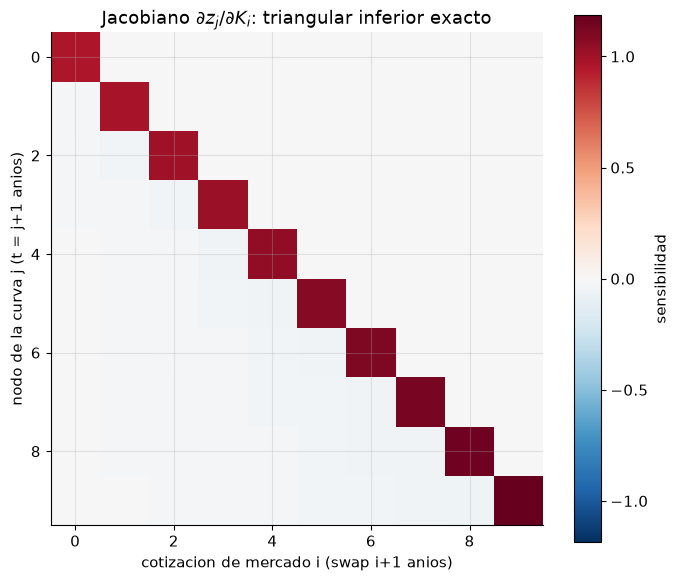


Error de 2.0bp en la cotizacion swap 5Y se propaga a la curva zero como:
  nodo 5Y: 2.1026 bp
  nodo 6Y: -0.0796 bp
  nodo 7Y: -0.0686 bp
  nodo 8Y: -0.0602 bp
  nodo 9Y: -0.0537 bp
  nodo 10Y: -0.0484 bp


In [5]:
def bootstrap_swap_curve(swap_rates, swap_times):
    '''Sequential swap-only bootstrap (5.2, no deposits) -- for the Jacobian demo.'''
    known_t, known_df = [], []
    for K, t_n in zip(swap_rates, swap_times):
        prev_t, prev_df = np.array([0.0] + known_t), np.array(known_df)
        tau_known = np.diff(prev_t)
        sum_known = np.sum(tau_known * prev_df) if len(prev_df) else 0.0
        tau_n = t_n - (known_t[-1] if known_t else 0.0)
        df_n = (1.0 - K * sum_known) / (1.0 + K * tau_n)
        known_t.append(t_n); known_df.append(df_n)
    return np.array(known_t), np.array(known_df)


swap_times_10 = np.arange(1, 11, dtype=float)
swap_rates_base = [par_swap_rate(nelson_siegel_df, swap_times_10[:n]) for n in range(1, 11)]
t_swap, df_swap = bootstrap_swap_curve(swap_rates_base, swap_times_10)
z_swap_base = -np.log(df_swap) / t_swap

jacobian = np.zeros((10, 10))
shock = 1e-4
for i in range(10):
    rates_up = list(swap_rates_base)
    rates_up[i] += shock
    _, df_up = bootstrap_swap_curve(rates_up, swap_times_10)
    z_up = -np.log(df_up) / t_swap
    jacobian[:, i] = (z_up - z_swap_base) / shock

max_upper = np.max(np.abs(np.triu(jacobian, k=1)))
print(f"max|elemento fuera de la triangular inferior| = {max_upper:.2e}  (debe ser exactamente 0)")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(jacobian, cmap="RdBu_r", vmin=-np.abs(jacobian).max(), vmax=np.abs(jacobian).max())
ax.set_xlabel("cotizacion de mercado i (swap i+1 anios)")
ax.set_ylabel("nodo de la curva j (t = j+1 anios)")
ax.set_title("Jacobiano $\\partial z_j/\\partial K_i$: triangular inferior exacto")
plt.colorbar(im, ax=ax, label="sensibilidad")
plt.tight_layout()
plt.show()

# propagacion de un error de cotizacion
error_quote_idx = 4   # error en la cotizacion del swap 5Y
error_bp = 2.0
propagated_error = jacobian[:, error_quote_idx] * error_bp * 1e4 * 1e-4 * 1e4  # simplificado abajo
propagated_error_zero = jacobian[:, error_quote_idx] * (error_bp * 1e-4)
print(f"\nError de {error_bp}bp en la cotizacion swap {int(swap_times_10[error_quote_idx])}Y "
      f"se propaga a la curva zero como:")
for j in range(10):
    if abs(propagated_error_zero[j]) > 1e-10:
        print(f"  nodo {int(swap_times_10[j])}Y: {propagated_error_zero[j]*1e4:.4f} bp")

## 4. Validación

1. **DV01**: analítico (shock paralelo) vs bump-and-reprice a $\pm1$bp y $\pm5$bp, `atol=1e-6`.
2. **Suma de KRD = DV01 paralelo**: `rtol=1e-3`.
3. **Jacobiano triangular**: elementos fuera de la triangular inferior, `atol=1e-8` (deben ser exactamente cero, no aproximadamente).
4. **Cross-check QuantLib**: DV01 propio vs bump-and-reprice de un `ql.VanillaSwap` sobre una curva reconstruida en QuantLib con los mismos nodos, `atol=1e-5`.

In [6]:
import QuantLib as ql

# 1. DV01
for bp in (1.0, 5.0):
    curve_up_v = parallel_shift_curve(times, dfs, bp)
    curve_dn_v = parallel_shift_curve(times, dfs, -bp)
    fd = (swap_pv(curve_up_v.df, K10, payment_times_10y) - swap_pv(curve_dn_v.df, K10, payment_times_10y)) / (2 * bp)
    diff = abs(fd - dv01_parallel_analytic)
    print(f"DV01 bp={bp}: |diff| = {diff:.2e} (atol 1e-6? {diff < 1e-6})")
    assert diff < 1e-6

# 2. suma KRD
rel_err_krd = abs(sum_krd - dv01_parallel_analytic) / abs(dv01_parallel_analytic)
print(f"\nsuma KRD vs DV01 paralelo: rel_err = {rel_err_krd:.2e} (rtol 1e-3? {rel_err_krd < 1e-3})")
assert rel_err_krd < 1e-3

# 3. jacobiano triangular
print(f"jacobiano: max fuera de triangular = {max_upper:.2e} (atol 1e-8? {max_upper < 1e-8})")
assert max_upper < 1e-8

# 4. QuantLib cross-check
eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()


def ql_curve_handle(times, dfs):
    dates = [eval_date] + [eval_date + ql.Period(int(round(t * 365)), ql.Days) for t in times]
    discounts = [1.0] + list(dfs)
    curve_ql = ql.DiscountCurve(dates, discounts, day_count)
    curve_ql.enableExtrapolation()
    return ql.YieldTermStructureHandle(curve_ql)


dummy_index = ql.IborIndex("dummy", ql.Period(1, ql.Years), 0, ql.USDCurrency(), ql.NullCalendar(),
                            ql.Unadjusted, False, day_count)
handle_base = ql_curve_handle(times, dfs)
dummy_index_base = ql.IborIndex("dummy", ql.Period(1, ql.Years), 0, ql.USDCurrency(), ql.NullCalendar(),
                                 ql.Unadjusted, False, day_count, handle_base)
schedule = ql.Schedule(eval_date, eval_date + ql.Period(10, ql.Years), ql.Period(1, ql.Years), ql.NullCalendar(),
                        ql.Unadjusted, ql.Unadjusted, ql.DateGeneration.Forward, False)
swap_ql = ql.VanillaSwap(ql.VanillaSwap.Payer, 1.0, schedule, K10, day_count, schedule,
                          dummy_index_base, 0.0, day_count)
swap_ql.setPricingEngine(ql.DiscountingSwapEngine(handle_base))
pv_base_ql = swap_ql.NPV()

z_base_full = -np.log(dfs) / times
z_up_full = z_base_full + 1e-4
handle_up = ql_curve_handle(times, np.exp(-z_up_full * times))
dummy_index_up = ql.IborIndex("dummy", ql.Period(1, ql.Years), 0, ql.USDCurrency(), ql.NullCalendar(),
                               ql.Unadjusted, False, day_count, handle_up)
swap_ql_up = ql.VanillaSwap(ql.VanillaSwap.Payer, 1.0, schedule, K10, day_count, schedule,
                             dummy_index_up, 0.0, day_count)
swap_ql_up.setPricingEngine(ql.DiscountingSwapEngine(handle_up))
pv_up_ql = swap_ql_up.NPV()

z_dn_full = z_base_full - 1e-4
handle_dn = ql_curve_handle(times, np.exp(-z_dn_full * times))
dummy_index_dn = ql.IborIndex("dummy", ql.Period(1, ql.Years), 0, ql.USDCurrency(), ql.NullCalendar(),
                               ql.Unadjusted, False, day_count, handle_dn)
swap_ql_dn = ql.VanillaSwap(ql.VanillaSwap.Payer, 1.0, schedule, K10, day_count, schedule,
                             dummy_index_dn, 0.0, day_count)
swap_ql_dn.setPricingEngine(ql.DiscountingSwapEngine(handle_dn))
pv_dn_ql = swap_ql_dn.NPV()

dv01_ql = (pv_up_ql - pv_dn_ql) / 2.0
diff_ql = abs(dv01_ql - dv01_parallel_analytic)
print(f"\npv_base QuantLib = {pv_base_ql:.2e} (debe ser ~0, swap a la par)")
print(f"DV01 QuantLib = {dv01_ql:.8f} | propio = {dv01_parallel_analytic:.8f} | "
      f"diff = {diff_ql:.2e} (atol 1e-5? {diff_ql < 1e-5})")
assert diff_ql < 1e-5

print()
print("Validacion completa: 4/4 dentro de tolerancia.")

DV01 bp=1.0: |diff| = 1.22e-10 (atol 1e-6? True)
DV01 bp=5.0: |diff| = 3.06e-09 (atol 1e-6? True)

suma KRD vs DV01 paralelo: rel_err = 1.48e-07 (rtol 1e-3? True)
jacobiano: max fuera de triangular = 0.00e+00 (atol 1e-8? True)

pv_base QuantLib = 9.67e-06 (debe ser ~0, swap a la par)
DV01 QuantLib = 0.00082405 | propio = 0.00082350 | diff = 5.44e-07 (atol 1e-5? True)

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Ho, T.S.Y. (1992). *Key Rate Durations: Measures of Interest Rate Risks*. Journal of Fixed Income, 2(2), 29-44.
- Tuckman, B. & Serrat, A. (2011). *Fixed Income Securities*, 3rd ed., Wiley, cap. 5 (DV01, duration, key-rate durations).
- Hagan, P.S. & West, G. (2006). *Interpolation Methods for Curve Construction*. (relación entre la interpolación y la localidad de la sensibilidad, retomado de 5.4).